# Week 7 - Linear classification (solution)

Learning contents:
* Part 1: Least squares for classification (Lecture 13)
* Part 2: Logistic regression (Lecture 14)
* Part 3: Multi-class logistic regression (Optional but highly recommended, Lecture 14)
* Part 4: Multi-class logistic regression on the original representation (Optional, Lecture 14)
* Part 5: Perceptron (Optional, Lecture 13)

In [1]:
# Dependencies
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set_theme() # this import just makes the plots prettier
import numpy as np

## Data
We'll be working with a dataset of handwritten digits. 
Let visualise some examples.

In [2]:
# We're using a subset of two classes for now
digits = load_digits(n_class=2)

In [3]:
# Handy plotting functions
x_min, x_max = -40, 40
y_min, y_max = -40, 40

def plot_examples():
    show_num = 4
    _, axes = plt.subplots(1, show_num)
    images_and_labels = list(zip(digits.images, digits.target))
    for ax, (image, label) in zip(axes[:], images_and_labels[:show_num]):
        ax.set_axis_off()
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        ax.set_title('Label: %i' % label)

def plot_scatter(data, target, n_class=2, alpha=0.5):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap=plt.get_cmap('rainbow', n_class))
    plt.legend(*scatter.legend_elements(), loc="upper left", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

def plot_decision_boundary(weights, c=0.5):
    """Plot the line where the linear model output equals the threshold c.

    The boundary is  w0 + w1*x1 + w2*x2 = c,  i.e.
        x2 = -(w1/w2) * x1 + (c - w0)/w2.
    Use c=0.5 for least squares with {0,1} targets; c=0 for logistic /
    perceptron activations.
    """
    weights = np.asarray(weights).flatten()
    slope = - weights[1] / weights[2]
    intercept = (c - weights[0]) / weights[2]
    xx = np.linspace(x_min, x_max)
    yy = slope * xx + intercept
    plt.plot(xx, yy, 'k--')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

def plot_mesh(X, pred_fn, n_class=2):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = pred_fn(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.get_cmap('rainbow', n_class))
    plt.axis('tight')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)


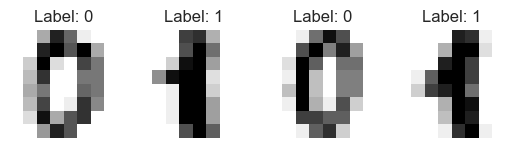

In [4]:
plot_examples()

In [5]:
# The dataset contains 2D data in the form of the `images` attribute, 
# as well as a 1D-version called `data`, where the images have been flattened. 
np.array_equal(digits.images[0].flatten(), digits.data[0])

True

In [6]:
# We can get a 2D version of the data using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(digits.data) # this is the representation, we'll be working with

In [7]:
# Out targets are in the set {0,1}
t_01 = digits.target

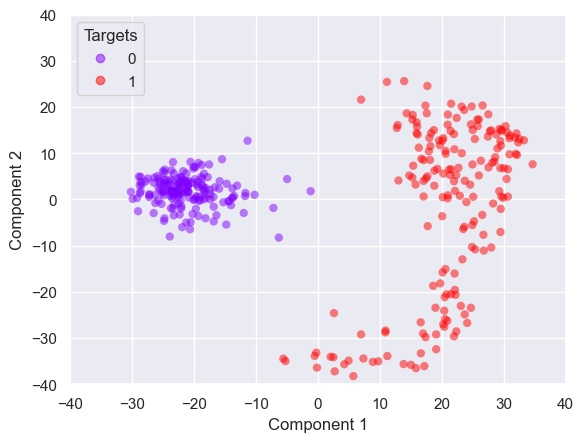

In [8]:
# Let's plot all the data in 2D
plot_scatter(X, t_01)

## Conventions used this week

Following the lecture notation (Lectures 13-14):

* **Bias augmentation:** we prepend a constant feature $\phi_0(x) = 1$, so $\Phi = [1, X]$ has shape (N, M+1) and the weight vector $\tilde{W} = (w_0, w_1, \dots, w_M)$ includes the bias $w_0$. With the 2-D PCA data, $X$ is (360, 2) and $\Phi$ is (360, 3).
* **Target coding:** Parts 1-2 use $t \in \{0, 1\}$; Parts 3-4 use a 1-of-K (one-hot) target matrix $T$ of shape (N, K); Part 5 (perceptron) uses $t \in \{-1, +1\}$.
* $\sigma(a) = 1/(1+e^{-a})$ is the logistic sigmoid; $\eta$ is the learning rate.

Each part below states which lecture it relies on. If your lab session falls before the week's second lecture (Lecture 14), start with Parts 1 and 5 (Lecture 13 only).

## 1) Least Squares

*Uses Lecture 13, slides 13 and 15. See the Conventions cell above for notation.*

### 1.1) Find the weight vector using Least Squares for classification
Hint: Remember to augment the data with a column of 1's

In [9]:
# Augment X with ones
def augment(X):
    """ Augment with bias component: phi_0(x) = 1.  X: (N, M) -> (N, M+1) """
    return np.hstack((np.ones((len(X),1)), X))

X_tilde = augment(X)

In [10]:
# Check an example
X_tilde[0]

array([  1.        , -24.84615349,   0.89358165])

In [11]:
# Compute the weights: W = (Phi^T Phi)^{-1} Phi^T t, via the pseudo-inverse
W_least_squares = np.linalg.pinv(X_tilde) @ t_01
W_least_squares = np.expand_dims(W_least_squares, axis=0)
assert X_tilde.shape == (360, 3) and W_least_squares.shape == (1, 3)
W_least_squares


array([[ 0.50555556,  0.02182423, -0.00478603]])

### 1.2) Create class predictions using the weight vector
You should be able to correctly classify all data

In [12]:
def predict(W, X_tilde, boundary=0.5):
    """Threshold the linear output y = W @ X_tilde.T at `boundary`.

    For least squares with {0,1} targets use boundary=0.5.
    For logistic regression, sigma(a) >= 0.5  <=>  a >= 0, so use
    boundary=0 on the linear activation.
    """
    y = (W @ X_tilde.T)[0]  # [0] unpacks the (1, N) row to (N,)
    preds = np.array(y > boundary, dtype=int)
    return preds

In [13]:
preds = predict(W_least_squares, X_tilde)

In [14]:
np.array_equal(t_01, preds)

True

### 1.3) Plot the decision boundary 
Hint: You can do this either by plotting a line on the boundary or creating a mesh of all predictions

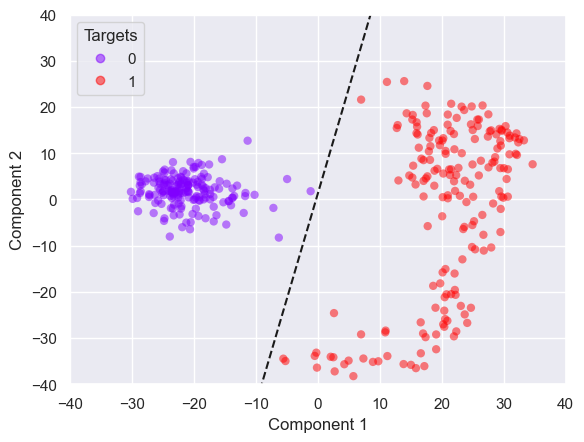

In [15]:
plot_scatter(X, t_01)
plot_decision_boundary(W_least_squares, c=0.5)

## 2) Logistic Regression

*Uses Lecture 14, slide 20.*
### 2.1) Find the weight vector using the Logistic Regression

In [16]:
X_train = augment(X)

# initialise W_0 randomly
np.random.seed(42)
W_0 = 2 * np.random.random((1, X_train.shape[1])) -1 # random values in the range [-1,1]

# Our target vectors should be {0, 1}
t = digits.target
W_0

array([[-0.25091976,  0.90142861,  0.46398788]])

In [17]:
def sigmoid(a):
    return 1/ (1 + np.exp(-a))

def error(W, X, t):
    """Gradient of the logistic cross-entropy error: (1/N) * PHI^T (y - t)."""
    y = sigmoid(W @ X.T).flatten()
    yt = (y - t)
    yt = np.broadcast_to(np.expand_dims(yt,axis=1), X.shape)
    return np.sum(yt*X, axis=0)/len(t)

In [18]:
learning_rate = 0.1
W_log = [W_0]
for epoch in range(30):
    W_log.append(W_log[epoch] - learning_rate * error(W_log[epoch], X_train, t))

W_logistic = W_log[-1]
W_logistic

array([[-0.23161682,  0.93318001, -0.21621897]])

### 2.2) Perform class-predictions

In [19]:
# Exact logistic rule: sigma(a) >= 0.5  <=>  a >= 0, so threshold at 0
preds = predict(W_logistic, X_train, boundary=0)
np.array_equal(preds, t)

True

### 2.3) Plot the decision boundary

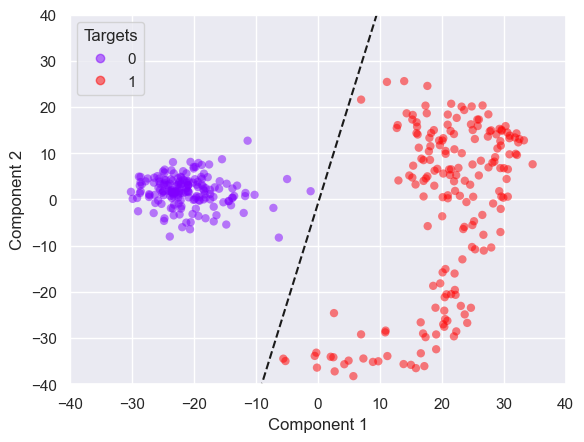

In [20]:
plot_scatter(X, t_01)
plot_decision_boundary(W_logistic, c=0)


## 3) Multi-class logistic regression (Optional but Highly Recommended)

*Uses Lecture 14 (multi-class logistic regression; textbook section 4.3.4).*
Repeat 2) but now for multiple classes, i.e. compute the weight matrix, perform predictions (you should be able to get about 93% accuracy) and plot decision boundaries.

Hint: You will need to use a one-hot encoding of the targets. See section 4.3.4 in the textbook.

In [21]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
pca = PCA(n_components=2)
X_mult = pca.fit_transform(digits.data)

learning_rate = 0.1

In [22]:
X_train_mult = augment(X_mult)

# We need to do a one_hot encoding of our data: 1 -> [0,1,0], 2 -> [0,0,1]
def one_hot(targets, n_class=n_class):
    res = np.eye(n_class)[np.array(targets).reshape(-1)]
    return res.reshape(list(targets.shape)+[n_class])

t_cat = digits.target
t_oh = one_hot(digits.target, n_class)

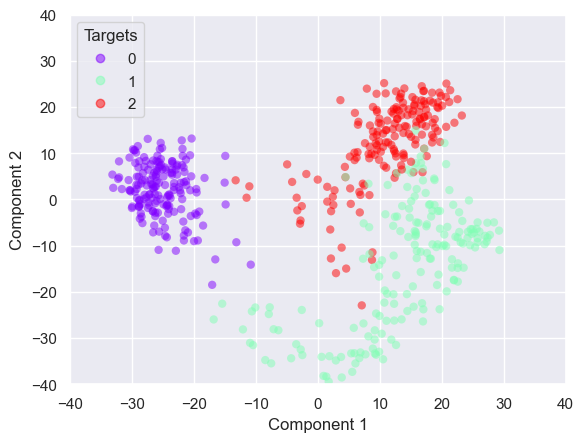

In [23]:
plot_scatter(X_mult, t_cat, n_class=n_class)

In [24]:
def softmax(x):
    e = np.exp(x - np.max(x))  # prevent overflow
    return e / np.maximum(np.sum(e, axis=0), 1e-16) # prevent divide by zero

def grad_error(W, X, t):
    """Gradient of the multi-class cross-entropy: (1/N) * PHI^T (Y - T),
    reshaped to W's shape. t is the one-hot target matrix of shape (N, K)."""
    y = softmax(W @ X.T).T
    yt = (y - t)
    yt_wide = np.repeat(yt, X.shape[1],1)
    X_wide = np.tile(X, (1, yt.shape[1]))
    return np.sum(yt_wide*X_wide, axis=0).reshape(W.shape) / X.shape[0]

def predict_multi(W, X):
    # Named predict_multi so it does not shadow the binary predict() from Part 1.
    y = softmax(W @ X.T).T
    return np.argmax(y, axis=1)

def accuracy(preds, targets):
    return np.sum(preds == targets) / len(targets)

In [25]:
# Weight initialisation
np.random.seed(25)
W_0 = 2 * np.random.random((n_class, X_train_mult.shape[1])) - 1
W_log_mult = [W_0]
epoch = 0

epoch = 0
acc =  0.39106145251396646


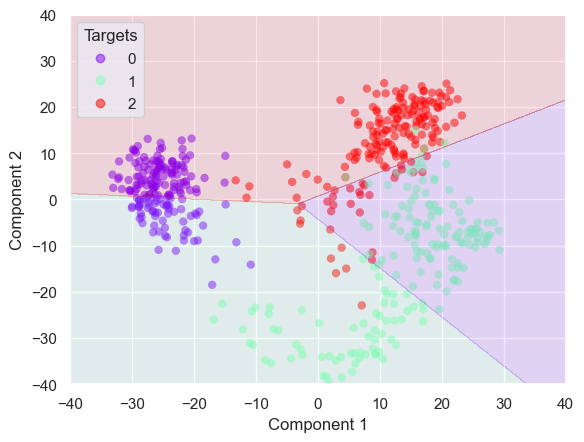

In [26]:
# Print metrics
print("epoch = {}".format(epoch))
# print("weight =  {}".format(W_log_mult[epoch]))
preds = predict_multi(W_log_mult[epoch], X_train_mult)
print("acc =  {}".format(accuracy(preds, t_cat)))

# Plot updates weight
plot_scatter(X_mult, t_cat, n_class=n_class)
plot_mesh(X_mult, lambda x: predict_multi(W_log_mult[epoch], augment(x)), n_class=n_class)

In [27]:
W_log_mult = [W_0]
for epoch in range(50):
    W_log_mult.append(W_log_mult[epoch] - learning_rate * grad_error(W_log_mult[epoch], X_train_mult, t_oh))

W_multi_logistic = W_log_mult[-1]

epoch = 49
acc =  0.9236499068901304


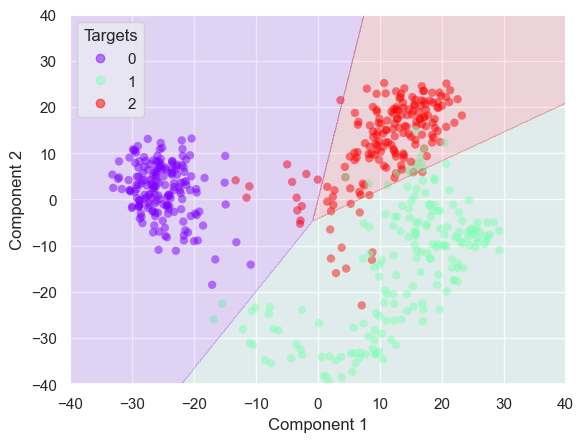

In [28]:
# Print metrics
print("epoch = {}".format(epoch))
# print("weight =  {}".format(W_log_mult[epoch]))
preds = predict_multi(W_log_mult[epoch], X_train_mult)
print("acc =  {}".format(accuracy(preds, t_cat)))

# Plot updates weight
plot_scatter(X_mult, t_cat, n_class=n_class)
plot_mesh(X_mult, lambda x: predict_multi(W_log_mult[epoch], augment(x)), n_class=n_class)

## 4) Multi-class logistic regression on original data representation (Optional Exercise)

*Uses Lecture 14.*
Repeat exercise 3), but use the original data representation instead.
You can omit the plots.

Hint: To get 100% accuracy, you can try to:
- Use the feature map $\phi(X) = [1, X, X^2]$ — bias, the 64 original pixel values, **and their squares** (129 features in total). With only $\phi(X) = [1, X]$ you will plateau below 100%.
- Rescale your data to the range [0,1]
- Run 1000 epochs with learning_rate = 0.1

In [29]:
def phi(X):
    """ Augment with bias component: phi_0(x) = 1 and squared values """
    return np.hstack((np.ones((len(X),1)), X, X**2))

X_train_mult_orig = phi(digits.data / digits.data.max()) 
X_train_mult_orig.shape   # 1 (bias) + 64 (pixels) + 64 (squared pixels) = 129 features

(537, 129)

In [30]:
# Weight initialisation
np.random.seed(25)
W_0 = 2 * np.random.random((n_class, X_train_mult_orig.shape[1])) - 1
W_0.shape

(3, 129)

In [31]:
W_log_mult_orig = [W_0]
for epoch in range(1000):
    W_log_mult_orig.append(W_log_mult_orig[epoch] - learning_rate * grad_error(W_log_mult_orig[epoch], X_train_mult_orig, t_oh))

W_mult_logistic_orig = W_log_mult_orig[-1]

In [32]:
preds = predict_multi(W_mult_logistic_orig, X_train_mult_orig)
print("acc =  {}".format(accuracy(preds, t_cat)))

acc =  1.0


## 5) Perceptron (Optional Exercise)

*Uses Lecture 13, slide 20.*

### 5.1) Set up and implement the Perceptron forward model

In [33]:
# Rebuild the 2-class data from Part 1 (Parts 3-4 overwrote `digits`)
digits2 = load_digits(n_class=2)
X_2 = PCA(n_components=2).fit_transform(digits2.data)   # (360, 2)
t_01_p5 = digits2.target                                # targets in {0, 1}

# Perceptron target coding: {0, 1} -> {-1, +1}
t_pm = 2 * t_01_p5 - 1

# phi(x) = [1, x1, x2]: polynomial basis of order 1, including phi_0(x) = 1
PHI_p5 = augment(X_2)                                   # (360, 3)

# Weight initialisation: random values in [-1, 1], seed 13
np.random.seed(13)
w_perceptron = 2 * np.random.random(3) - 1

learning_rate = 0.1
max_epochs = 1000

# Perceptron algorithm (Lecture 13, slide 20): for each misclassified point,
#   w <- w + eta * phi(x_n) * t_n      (a gradient step on E_P(w) = -sum w^T phi(x_n) t_n)
for epoch in range(max_epochs):
    updates = 0
    for n in range(len(PHI_p5)):
        a = w_perceptron @ PHI_p5[n]
        y_n = 1 if a >= 0 else -1               # activation f(a)
        if y_n != t_pm[n]:                      # misclassified
            w_perceptron = w_perceptron + learning_rate * PHI_p5[n] * t_pm[n]
            updates += 1
    if updates == 0:                            # full clean pass: converged
        break

print(f"converged after epoch {epoch} (no updates); w = {w_perceptron}")


converged after epoch 1 (no updates); w = [ 0.65540482  5.01880092 -1.25584364]


### 5.2) Perform class-predictions
All 360 points are classified correctly — the data is linearly separable, so the perceptron converges (here after two passes over the data), long before the 1000-epoch cap.

In [34]:
# Predictions: f(a) in {-1, +1}, mapped back to {0, 1} for the comparison
a = PHI_p5 @ w_perceptron
preds_pm = np.where(a >= 0, 1, -1)
preds_p5 = (preds_pm + 1) // 2                  # {-1, +1} -> {0, 1}
print(np.array_equal(t_01_p5, preds_p5))        # True: all 360 classified correctly


True


### 5.3) Plot the decision boundary

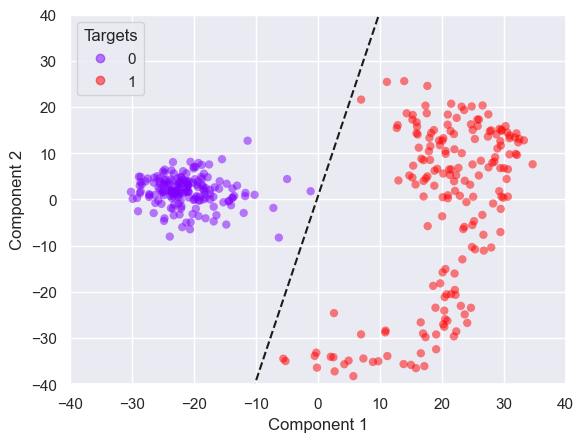

In [35]:
plot_scatter(X_2, t_01_p5)
plot_decision_boundary(w_perceptron, c=0)       # the perceptron thresholds the activation at 0
